In [1]:
import os
for k in ["http_proxy","https_proxy","all_proxy","HTTP_PROXY","HTTPS_PROXY","ALL_PROXY","NO_PROXY","no_proxy"]:
    os.environ.pop(k, None)
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

import torch
import numpy as np
from diffusers import StableDiffusionPipeline
import random
from tqdm import tqdm
import pandas as pd
import os
import argparse
# from clip_score_cal import CLIP_Score
import torch
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
from functools import partial
import matplotlib.pyplot as plt
import uuid 
from torchvision.utils import make_grid
from torchvision import transforms

negative_prompt = "bad anatomy,watermark,extra digit,signature,worst quality,jpeg artifacts,normal quality,low quality,long neck,lowres,error,blurry,missing fingers,fewer digits,missing arms,text,cropped,Humpbacked ,bad hands,username"
MODEL_NAME="CompVis/stable-diffusion-v1-4"

In [6]:
# Some functions we need


def get_target_module(target_pipe, block='mid', layer_id=[0,0,0]):
    """
    get the target attention module in unet according to the block and layer_id.
    """
    block_id = layer_id[0]
    attn_id = layer_id[1]
    tsfm_id = layer_id[2]
    if block == 'mid':
        assert attn_id < 3 and tsfm_id < 1
        target_layer = target_pipe.unet.mid_block.attentions[attn_id].transformer_blocks[tsfm_id].attn2
    elif block == 'up':
        # unet.up_blocks[1:4] are CrossAttnUpBlock2D, which has XAttention
        assert 1< block_id < 4 and attn_id < 3 and tsfm_id < 1
        target_layer = target_pipe.unet.up_blocks[block_id].attentions[attn_id].transformer_blocks[tsfm_id].attn2
    elif block == 'down':
        # unet.down_blocks[0:4] are CrossAttnUpBlock2D, which has XAttention, but only has up to 2 attentions,
        # attn_id<=1
        assert block_id<4 and attn_id < 2 and tsfm_id < 1
        target_layer = target_pipe.unet.down_blocks[block_id].attentions[attn_id].transformer_blocks[tsfm_id].attn2
    else:
        raise KeyError
    return target_layer

@torch.no_grad()
def get_embedding(target_pipe, 
                  path_2_template, 
                  use_text_prompt=True,
                  path_2_ti=None,
                  ti_key='<style>',
                  concept='van gogh', 
                  rest_concepts=[],
                  postion = 'text_encoder',
                  block = 'mid',
                  layer_id=[0,0,0],
                  split_uncon=False,
                  num_prompt=1000):
    """
    get the embeddings at the target layer when the target concept is present or not. 
    If split_uncon is True, only the unconditional part of the embedding will be collected.
    """
    act={}
    rest_act = {}
    cnt = 0
    target_pipe.set_progress_bar_config(disable=True)
    if postion == 'text_encoder':
        target_module = target_pipe.text_encoder.encoder.layers[layer_id[0]].self_attn.out_proj
        hook_hanlder = target_module.register_forward_hook(
            partial(get_activation, 'target', act, split_uncon))
        
        with open(path_2_template, 'r') as file:
            templates = [line.strip() for line in file if line.strip()]
        templates = templates[:num_prompt]

        for line in templates:
            prompt = line.format(concept)
            text_inputs = target_pipe.tokenizer(
                prompt,
                max_length=target_pipe.tokenizer.model_max_length,
                truncation=True,
                return_tensors="pt",
            )
            prompt_embeds = target_pipe.text_encoder(
                text_inputs.input_ids.to(target_pipe.device),
                attention_mask=text_inputs.attention_mask.to(target_pipe.device),
            )[0][0]
  
        emb_lst = torch.cat(act['target'], dim=1).squeeze(0)
        act.clear()
        act = emb_lst

    elif postion == 'unet_self_attn':
        """
        unet has lots of blocks, each contains a attn2 module which does the cross attention 
        so we should choose only one block.
        """
        target_module = get_target_module(target_pipe, block, layer_id)
        hook_hanlder = target_module.to_v.register_forward_hook(
            partial(get_activation, 'target', act, split_uncon))
        with open(path_2_template, 'r') as file:
            templates = [line.strip() for line in file if line.strip()]
        templates = templates[:num_prompt]

        if use_text_prompt:    
            for line in templates:
                prompt = line.format(concept)
                res = target_pipe(prompt,
                            negative_prompt=None,
                            # generator=torch.manual_seed(2025),
                            num_inference_steps=1,
                            )[0]
        if isinstance(path_2_ti, list):
            for p2ti in path_2_ti:
                if os.path.exists(p2ti):
                    target_pipe.load_textual_inversion(str(p2ti))
                    for line in templates:
                        prompt = line.format(ti_key)
                        res = target_pipe(prompt,
                                    negative_prompt=None,
                                    generator=torch.manual_seed(2025),
                                    num_inference_steps=1,
                                    )[0]
        hook_hanlder.remove()

        for rest_c in rest_concepts:
            hook_hanlder = target_module.to_v.register_forward_hook(
            partial(get_activation, 'rest', rest_act, split_uncon))
            with open(path_2_template, 'r') as file:
                for line in file:
                    prompt = line.format(concept)
                    res = target_pipe(prompt,
                                negative_prompt=None,
                                generator=torch.manual_seed(2025),
                                num_inference_steps=1,
                                )[0]
    return act, rest_act

def get_activation(layer_name, act, split_uncon, layer, inp, out):
    if layer_name in act.keys():
        if split_uncon:
            size = inp[0].shape[0]
            act[layer_name].append(inp[0][size//2:].cpu().detach())
        else:
            act[layer_name].append(inp[0].cpu().detach())
    else:
        if split_uncon:
            size = inp[0].shape[0]
            act[layer_name] = [inp[0][size//2:].cpu().detach()]
        else:
            act[layer_name] = [inp[0].cpu().detach()]

class PipeWithHookerForPromptEmbed(StableDiffusionPipeline):
    """
    a customized pipeline that returns the prompt embedding .
    """
    @torch.no_grad()
    def encode_prompt(
        self,
        prompt,
        device,
        num_images_per_prompt=1,
        do_classifier_free_guidance=False,
        negative_prompt=None,
        prompt_embeds=None,
        negative_prompt_embeds=None,
        lora_scale=None,
        clip_skip=None,
        **kwargs,
    ):
        # 1) 自己 tokenize 一次，拿到 attention_mask（只针对 positive）
        text_inputs = self.tokenizer(
            prompt if isinstance(prompt, list) else [prompt],
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        )
        pos_attention_mask = text_inputs.attention_mask.to(device)  # [B,77]
        
        # 2) 走原版 encode_prompt 得到 prompt_embeds / negative_prompt_embeds
        prompt_embeds, negative_prompt_embeds = super().encode_prompt(
            prompt=prompt,
            device=device,
            num_images_per_prompt=num_images_per_prompt,
            do_classifier_free_guidance=do_classifier_free_guidance,
            negative_prompt=negative_prompt,
            prompt_embeds=prompt_embeds,
            negative_prompt_embeds=negative_prompt_embeds,
            lora_scale=lora_scale,
            clip_skip=clip_skip,
            **kwargs,
        )

        # --- remove pad tokens (ONLY for analysis, not modifying embeds yet) ---
        mask = pos_attention_mask.bool()
        valid_hidden = torch.cat(
            [prompt_embeds[i][mask[i]] for i in range(prompt_embeds.shape[0])],
            dim=0,
        )

        # --- cache for external use ---
        self._last_valid_hidden = valid_hidden.detach().float().cpu()
        self._last_attention_mask = pos_attention_mask.detach().cpu()

        return prompt_embeds, negative_prompt_embeds

def help_embedding(args):
    pipe_hooker = PipeWithHookerForPromptEmbed.from_pretrained(MODEL_NAME,
                                        torch_dtype=torch.float16,
                                        safety_checker = None).to(device)
    collect_embedding, resc_embedding =get_embedding(pipe_hooker,
                                                    args.path_2_prompt_template, 
                                                    use_text_prompt=True,
                                                    concept=args.target_concept, 
                                                    rest_concepts=['cat'],
                                                    postion=args.proj_position,
                                                    block=args.block,
                                                    layer_id=args.layer_id,
                                                    split_uncon=args.split_uncon,
                                                    num_prompt=args.num_prompt_pre)
    del pipe_hooker
    return collect_embedding


def project_text_conder_attn(pipe, proj_matrix, layer_id=11):
    target_layer = pipe.text_encoder.encoder.layers[layer_id].self_attn.out_proj
    org_weight = target_layer.weight.data.clone()
    target_layer.weight.data = torch.matmul(
        org_weight, proj_matrix.to(org_weight.device).to(org_weight.dtype))


def get_basis(emebd, rank=1):
    X = emebd.reshape(-1, 768).to(torch.float32)
    # X = X - X.mean(dim=0, keepdim=True)
    U, S, V = torch.svd(X.T)
    if isinstance(rank, list):
        subspace = torch.matmul(U[:, rank[0]:rank[1]], U[:, rank[0]:rank[1]].T)
    else:
        subspace = torch.matmul(U[:, :rank], U[:, :rank].T)
    return subspace, S

def get_proj(emebd, rank=1, lam=1, plot=False):
    subspace, S = get_basis(emebd, rank=rank)
    proj = torch.eye(subspace.shape[0])-lam*subspace
    if plot:
        return proj, S
    else:
        return proj
      
def plot_exp_var(S, rank=40):
    rank = min(rank, S.shape[0])
    plt.figure(figsize=(4, 4), dpi=100)
    colors = ['tab:red'] + ['gray'] * (rank - 1)
    hatches = ['//'] + ['.'] * (rank - 1)  # Add stripes only to the first bar
    # Plot the bars with specified colors
    bars = plt.bar(np.arange(1, rank + 1), height=(S**2 / (S**2).sum())[:rank], color=colors)
    # Apply hatching
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)
    plt.grid()
    plt.ylabel('Explained variance ratio')
    plt.yscale('log')


@torch.no_grad()
def generate_img(pipe, prompt, num_img=12, negative_prompt=None, seed=None):
    res = []
    try:
        pipe.set_progress_bar_config(disable=True)
    except:
        pass
    for i in range(num_img):
        if seed:
            g = torch.Generator(device=pipe.unet.device).manual_seed(seed+i*100)
            latents = torch.randn(
                (1, pipe.unet.config.in_channels, 64, 64),
                generator=g,
                device=pipe.unet.device,
                dtype=pipe.unet.dtype,
                )
            image = pipe(
                prompt=prompt,
                latents=latents,
                negative_prompt=negative_prompt,
                )[0]
        else:
            image =pipe(prompt=prompt,
                    negative_prompt=negative_prompt,
                    )[0]
        res.append(image)
    res = [i[0] for i in res]
    return res

def showimages(images, 
                prompt=None, 
                max_per_row = 6, 
                transpose=False, 
                save_dir='temp_folder',
                prefix=None,
                padding=0,
                save=True,
                show_dpi=20,
                save_dpi=300):
    os.makedirs(save_dir, exist_ok=True)
    # Define transform to convert PIL images to tensors
    to_tensor = transforms.ToTensor()
    
    if transpose:
        temp_images = []
        for j in range(max_per_row):
            for i in range(j, len(images), max_per_row):
                temp_images.extend([images[i]])
        images = temp_images

    # Convert each image to a PyTorch tensor
    images_tensor = torch.stack([to_tensor(image) for image in images])

    if transpose:
        grid = make_grid(images_tensor, nrow=len(images)//max_per_row, padding=10, pad_value=1)
    else:
        grid = make_grid(images_tensor, nrow=max_per_row, padding=10, pad_value=1)

    # Convert the grid to numpy format for displaying with matplotlib
    grid_np = grid.permute(1, 2, 0).numpy()
    if transpose:
        plt.figure(figsize=((len(images) // max_per_row + 1) * 1, max_per_row * 1), dpi=show_dpi)
    else:   
        plt.figure(figsize=(max_per_row * 1, (len(images) // max_per_row + 1) * 1), dpi=show_dpi)
    plt.imshow(grid_np)
    plt.axis("off")
    if prompt:
        plt.title(prompt, fontsize=15)
    plt.tight_layout(pad=-50)
    plt.show()
    plt.close()

    if transpose:
        plt.figure(figsize=((len(images) // max_per_row + 1) * 2, max_per_row * 2), dpi=save_dpi)
    else:   
        plt.figure(figsize=(max_per_row * 2, (len(images) // max_per_row + 1) * 2), dpi=save_dpi)
    if save:
        plt.imshow(grid_np)
        plt.axis("off")
        plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
        fig_name = str(uuid.uuid1())
        if prefix:
            fig_name = prefix + fig_name
        plt.savefig(f"{save_dir}/{fig_name}.png", bbox_inches='tight')
        torch.save(images, f"{save_dir}/{fig_name}.pth")
        print(f"save pdf {save_dir}/{fig_name}.png, raw data at {save_dir}/{fig_name}.pth")
        plt.close()

        
# If you want to detect the present rate of target concpet presented 
# in the generated images, you can use the following code:
device = torch.device("cuda") 
model_id = "openai/clip-vit-large-patch14"
model = CLIPModel.from_pretrained(model_id).to(device).eval()
processor = CLIPProcessor.from_pretrained(model_id)

@torch.inference_mode()
def clip_score(model, processor, device, imgs, prompt):
    # images = [Image.open(p).convert("RGB") for p in imgs]
    inputs = processor(
        text=prompt,
        images=imgs,
        return_tensors="pt",
        padding=True,
    ).to(device)

    num_car = 0
    total = 0
    
    # logits_per_image: [B, 2] (image-to-text similarity, already scaled)
    outputs = model(**inputs)
    logits = outputs.logits_per_image  # [B, 2]

    pred = logits.argmax(dim=1)  # 0 => car, 1 => without car
    num_car += (pred == 0).sum().item()
    total += logits.size(0)
    return {"total": total, "num_car": num_car, "car_ratio": num_car / max(total, 1)}

CAR_PROMPTS = [
    'a photo of a car'
]

@torch.inference_mode()
def clip_car_scores(model, processor, device, imgs, prompt):
    text_inputs = processor(
        text=prompt,
        return_tensors="pt",
        padding=True
    ).to(device)

    text_features = model.get_text_features(**text_inputs)

    # compatibility with newer transformers
    if hasattr(text_features, "pooler_output"):
        text_features = text_features.pooler_output

    text_features = text_features / text_features.norm(
        dim=-1,
        keepdim=True
    )

    image_inputs = processor(
        images=imgs,
        return_tensors="pt"
    ).to(device)

    image_features = model.get_image_features(**image_inputs)

    # compatibility with newer transformers
    if hasattr(image_features, "pooler_output"):
        image_features = image_features.pooler_output

    image_features = image_features / image_features.norm(
        dim=-1,
        keepdim=True
    )

    sim = image_features @ text_features.T

    return sim.mean(dim=1).cpu()

def car_detection_rate(scores, threshold):
    return (scores > threshold).float().mean().item()


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

In [3]:
arg = argparse.ArgumentParser()
arg.add_argument('--proj_position', type=str, default='text_encoder', 
                 help='the position to project, choose from [unet_self_attn, text_encoder]')
arg.add_argument('--target_concept', type=str, default='car',)
arg.add_argument('--num_img', type=int, default=10,)
arg.add_argument('--num_prompt_pre', type=int, default=1,)
arg.add_argument('--num_prompt_gen', type=int, default=30,)
arg.add_argument('--seed', type=int, default=2025,)
arg.add_argument('--path_2_prompt_template', type=str, default='./1000_short_t2i_prompts.txt',)
arg.add_argument('--num_rest_concepts', type=int, default=4,)
arg.add_argument('--model_name', type=str, default='CompVis/stable-diffusion-v1-4',)
arg.add_argument('--test_run', action='store_true', 
                 help='whether to do a test run with reduced settings')
arg.add_argument('--save_path', type=str, default='tdsc_rebuttal_results_adavd_template2')
arg.add_argument('--block', type=str, default='mid')
arg.add_argument('--layer_id', type=list, default=[0, 0, 0])
arg.add_argument('--split_uncon', type=bool, default=False)

device = torch.device("cuda") 

DEFAULT_REST_CONCEPT_POOL = [
    "Vincent van Gogh",
    "Pablo Picasso",
    "Claude Monet",
    "Andy Warhol",
    "Amerighi da Caravaggio"
]

args = arg.parse_args([])

args.num_prompt_pre = 20
args.path_2_prompt_template = './1000_short_t2i_prompts.txt'



# Erase Taylor Swift

/opt/conda/lib/python3.11/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class '__main__.PipeWithHookerForPromptEmbed'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


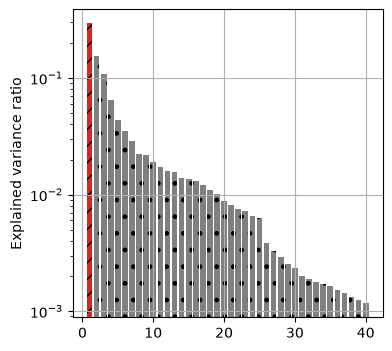

In [4]:
args.target_concept = 'Taylor Swift'

proj_pipe = StableDiffusionPipeline.from_pretrained(MODEL_NAME,
                                                    torch_dtype=torch.float16,
                                                    safety_checker = None,).to(device)

collect_embedding = help_embedding(args)

U, S, V = torch.svd(collect_embedding.reshape(-1, 768).cpu().to(torch.float32).T)

proj_matrix = torch.eye(U.shape[0])-4*torch.matmul(U[:, :1], U[:, :1].T)

project_text_conder_attn(proj_pipe, proj_matrix, layer_id=0)

plot_exp_var(S)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


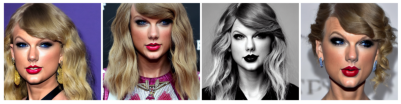

save pdf temp_folder/1f185fe0-a96e-11f1-ac42-eeaab3fc1772.png, raw data at temp_folder/1f185fe0-a96e-11f1-ac42-eeaab3fc1772.pth


AttributeError: 'BaseModelOutputWithPooling' object has no attribute 'norm'

In [5]:
prompt = f"a portrait of {args.target_concept}"

sd_pipe = StableDiffusionPipeline.from_pretrained(MODEL_NAME,
                                                    torch_dtype=torch.float16,
                                                    safety_checker = None,).to(device)

before_image = generate_img(sd_pipe, 
                    prompt, 
                    num_img=4, 
                    negative_prompt=negative_prompt,
                    seed=2025
                    )
showimages(before_image) 
before_score = clip_car_scores(model, processor, device, before_image, 'a photo of a Taylor Swift')
threshold = before_score.mean()
threshold, before_score

In [7]:
before_score = clip_car_scores(
    model,
    processor,
    device,
    before_image,
    'a photo of Taylor Swift'
)

threshold = before_score.mean()

print("Before scores:", before_score)
print("Mean:", threshold)

Before scores: tensor([0.2404, 0.2425, 0.2548, 0.2664])
Mean: tensor(0.2510)


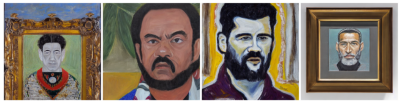

save pdf temp_folder/ba63ea26-a970-11f1-ac42-eeaab3fc1772.png, raw data at temp_folder/ba63ea26-a970-11f1-ac42-eeaab3fc1772.pth


In [8]:
after_image = generate_img(
    proj_pipe,
    prompt,
    num_img=4,
    negative_prompt=negative_prompt,
    seed=2025
)

showimages(after_image)